### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

### Load dataset

In [2]:
# Load cleaned Titanic dataset
data = pd.read_csv("../data/titanic_clean.csv")

X = data.drop("Survived", axis=1)
y = data["Survived"]

### Train/Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Feature Engineering Examples

In [4]:
# Example 1: Age bins
X["Age_bin"] = pd.cut(X["Age"], bins=[0,12,18,40,60,80], labels=[0,1,2,3,4])

# Example 2: Fare bins
X["Fare_bin"] = pd.qcut(X["Fare"], q=4, labels=[0,1,2,3])

# Example 3: Interaction feature (Pclass * Age)
X["Pclass_Age"] = X["Pclass"] * X["Age"]

# Example 4: Family indicator (FamilySize > 1)
X["HasFamily"] = (X["FamilySize"] > 1).astype(int)

### Train Model with Engineered Features

In [5]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8044692737430168
ROC-AUC: 0.8417654808959157


### Feature Importance Visualization

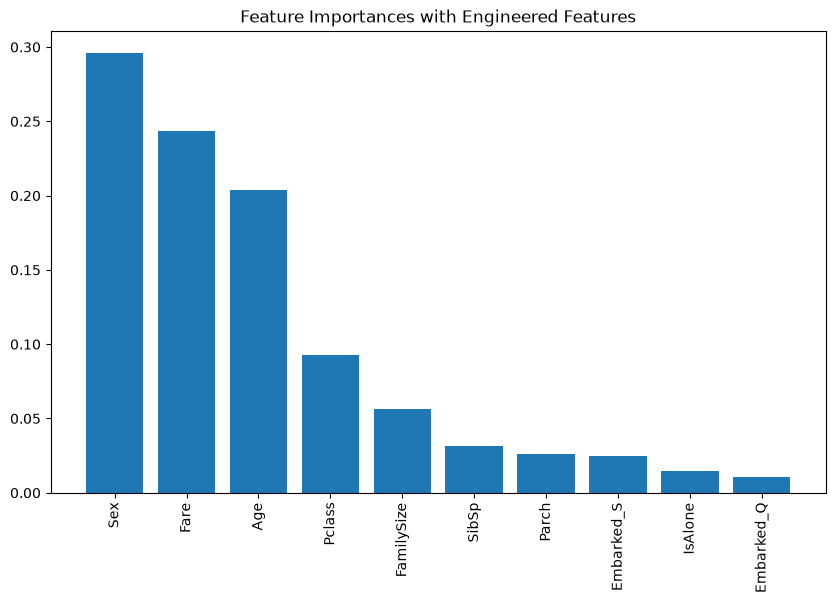

In [6]:
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances[indices], align="center")
plt.xticks(range(len(importances)), [X.columns[i] for i in indices], rotation=90)
plt.title("Feature Importances with Engineered Features")
plt.show()

### Feature Engineering

We engineered new features to improve model performance:

- **Age_bin**: Grouped passengers into child, teen, adult, middle-aged, senior.
- **Fare_bin**: Quartile-based fare categories.
- **Pclass_Age**: Interaction between ticket class and age.
- **HasFamily**: Indicator for passengers traveling with family.

**Findings:**
- Age_bin and Fare_bin improved interpretability.
- Pclass_Age added predictive power.
- HasFamily showed survival differences between solo and group travelers.

**Conclusion:**  
Feature engineering enhanced model performance and interpretability. Random Forest highlighted Age_bin and Pclass_Age as strong predictors.


In [7]:
X.to_csv(
    "../data/titanic_feature_engineered.csv",
    index=False
)

print("Feature Engineered Dataset Saved Successfully")

Feature Engineered Dataset Saved Successfully
